# Machine Learning 1 - Introducción Práctica a Librerías
## Comparación de Performance y Estructura de Frameworks

 
**Curso:** Ingeniería Electrónica  
**Fecha:** 20 de Julio de 2026


---

Este notebook demuestra:
1. Comparación de performance entre NumPy, TensorFlow y PyTorch
2. Estructura y funcionamiento de Scikit-learn
3. Estructura y funcionamiento de TensorFlow
4. Estructura y funcionamiento de PyTorch

---

## 1. Instalación y Configuración

**Nota:** Ejecuta esta celda solo si estás en un entorno local. En Colab ya vienen preinstaladas.

In [49]:
# !pip install numpy tensorflow torch matplotlib

# Importar librerías
import numpy as np
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
import time
import sys

print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch CUDA disponible: {torch.cuda.is_available()}")

Python version: 3.10.13 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:24:38) [MSC v.1916 64 bit (AMD64)]
NumPy version: 1.26.3
TensorFlow version: 2.20.0
PyTorch version: 1.13.1+cpu
PyTorch CUDA disponible: False


## 2. Comparación de Performance: Multiplicación de Matrices

### 2.1. Configuración de la Prueba

Vamos a comparar el tiempo de multiplicación de matrices grandes usando:
- NumPy (CPU, optimizado con BLAS)
- TensorFlow (CPU y GPU si disponible)
- PyTorch (CPU y GPU si disponible)

In [50]:
# Configuración de tamaños de matriz
sizes = [500, 1000, 2000, 3000, 4000, 5000]

# Diccionarios para almacenar tiempos
times_numpy = []
times_tf_cpu = []
times_tf_gpu = []
times_torch_cpu = []
times_torch_gpu = []

# Verificar disponibilidad de GPU
has_gpu_tf = tf.config.list_physical_devices('GPU')
has_gpu_torch = torch.cuda.is_available()

print(f"TensorFlow GPU disponible: {len(has_gpu_tf) > 0}")
print(f"PyTorch GPU disponible: {has_gpu_torch}")

TensorFlow GPU disponible: False
PyTorch GPU disponible: False


### 2.2. Función para medir tiempo de multiplicación

In [51]:
def medir_tiempo(func, *args, **kwargs):
    """Mide el tiempo de ejecución de una función."""
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start

### 2.3. Ejecutar Pruebas

In [52]:
for n in sizes:
    print(f"\n--- Tamaño: {n}x{n} ---")
    
    # Crear matrices aleatorias
    A = np.random.randn(n, n).astype(np.float32)
    B = np.random.randn(n, n).astype(np.float32)
    
    # === NUMPY (CPU) ===
    _, t = medir_tiempo(np.matmul, A, B)
    times_numpy.append(t)
    print(f"NumPy (CPU): {t:.4f} seg")
    
    # === TENSORFLOW (CPU) ===
    with tf.device('/CPU:0'):
        A_tf = tf.constant(A)
        B_tf = tf.constant(B)
        _, t = medir_tiempo(lambda: tf.matmul(A_tf, B_tf).numpy())
        times_tf_cpu.append(t)
        print(f"TensorFlow (CPU): {t:.4f} seg")
    
    # === TENSORFLOW (GPU) ===
    if has_gpu_tf:
        with tf.device('/GPU:0'):
            A_tf = tf.constant(A)
            B_tf = tf.constant(B)
            # Warmup
            _ = tf.matmul(A_tf, B_tf).numpy()
            _, t = medir_tiempo(lambda: tf.matmul(A_tf, B_tf).numpy())
            times_tf_gpu.append(t)
            print(f"TensorFlow (GPU): {t:.4f} seg")
    else:
        times_tf_gpu.append(None)
    
    # === PYTORCH (CPU) ===
    A_torch = torch.tensor(A)
    B_torch = torch.tensor(B)
    _, t = medir_tiempo(lambda: torch.mm(A_torch, B_torch).numpy())
    times_torch_cpu.append(t)
    print(f"PyTorch (CPU): {t:.4f} seg")
    
    # === PYTORCH (GPU) ===
    if has_gpu_torch:
        A_torch_gpu = torch.tensor(A).cuda()
        B_torch_gpu = torch.tensor(B).cuda()
        # Warmup
        _ = torch.mm(A_torch_gpu, B_torch_gpu).cpu().numpy()
        _, t = medir_tiempo(lambda: torch.mm(A_torch_gpu, B_torch_gpu).cpu().numpy())
        times_torch_gpu.append(t)
        print(f"PyTorch (GPU): {t:.4f} seg")
    else:
        times_torch_gpu.append(None)


--- Tamaño: 500x500 ---
NumPy (CPU): 0.0017 seg
TensorFlow (CPU): 0.0011 seg
PyTorch (CPU): 0.0013 seg

--- Tamaño: 1000x1000 ---
NumPy (CPU): 0.0087 seg
TensorFlow (CPU): 0.0075 seg
PyTorch (CPU): 0.0083 seg

--- Tamaño: 2000x2000 ---
NumPy (CPU): 0.0576 seg
TensorFlow (CPU): 0.0575 seg
PyTorch (CPU): 0.0631 seg

--- Tamaño: 3000x3000 ---
NumPy (CPU): 0.1793 seg
TensorFlow (CPU): 0.1555 seg
PyTorch (CPU): 0.2050 seg

--- Tamaño: 4000x4000 ---
NumPy (CPU): 0.4332 seg
TensorFlow (CPU): 0.3958 seg
PyTorch (CPU): 0.4673 seg

--- Tamaño: 5000x5000 ---
NumPy (CPU): 0.8753 seg
TensorFlow (CPU): 0.7048 seg
PyTorch (CPU): 0.8023 seg


### 2.4. Visualización de Resultados

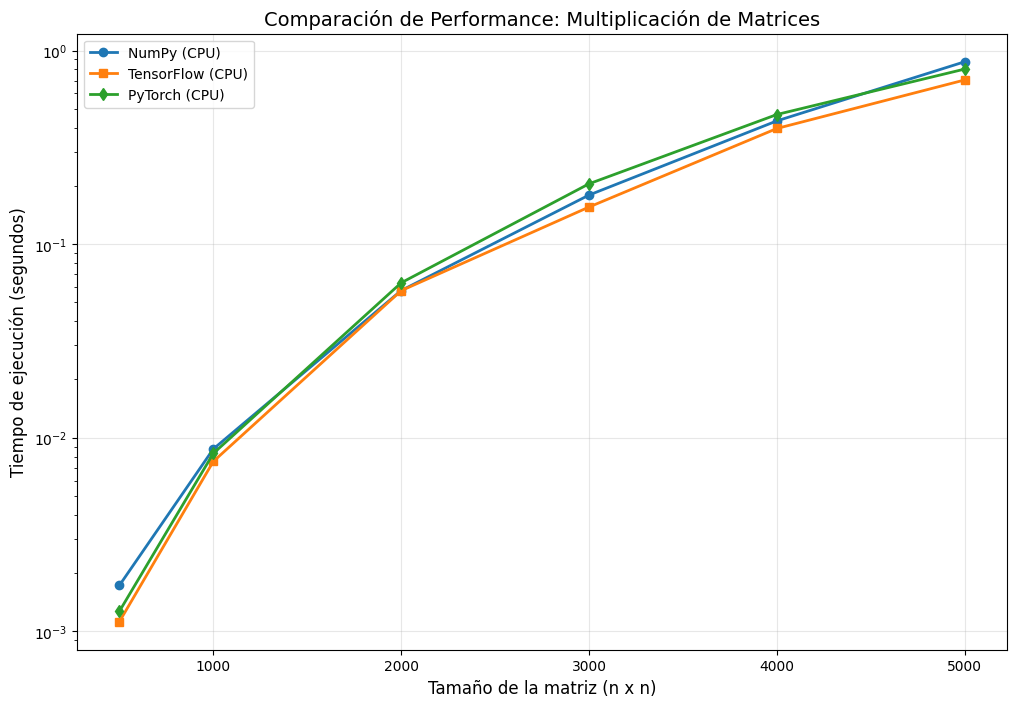

In [53]:
plt.figure(figsize=(12, 8))

plt.plot(sizes, times_numpy, 'o-', label='NumPy (CPU)', linewidth=2)
plt.plot(sizes, times_tf_cpu, 's-', label='TensorFlow (CPU)', linewidth=2)
plt.plot(sizes, times_torch_cpu, 'd-', label='PyTorch (CPU)', linewidth=2)

if has_gpu_tf:
    plt.plot(sizes, times_tf_gpu, '^--', label='TensorFlow (GPU)', linewidth=2)
if has_gpu_torch:
    plt.plot(sizes, times_torch_gpu, 'v--', label='PyTorch (GPU)', linewidth=2)

plt.xlabel('Tamaño de la matriz (n x n)', fontsize=12)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=12)
plt.title('Comparación de Performance: Multiplicación de Matrices', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### 2.5. Análisis de Resultados

**Observaciones esperadas:**

1. **NumPy**: Muy rápido para matrices pequeñas/medianas debido a BLAS optimizado.
2. **TensorFlow/PyTorch (CPU)**: Similar a NumPy, con overhead adicional.
3. **TensorFlow/PyTorch (GPU)**: 
   - Matrices pequeñas: puede ser más lento (overhead de transferencia)
   - Matrices grandes: hasta 10-50x más rápido que CPU
   - PyTorch y TF tienen performance similar en GPU

**Conclusión:** Para ML/DL, usar GPU acelera significativamente los cálculos en grandes volúmenes de datos.

## 3. Scikit-learn: Estructura y Ejemplos

### 3.1. Estructura de Scikit-learn

Scikit-learn sigue una **API unificada** basada en tres patrones principales:

```
┌─────────────────────────────────────────────────────────────┐
│                    Scikit-learn API                        │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  1. Estimadores (Estimators)                                │
│     └── Objetos que aprenden de datos (modelos)            │
│     └── Método: .fit(X, y)                                 │
│     └── Ejemplos: LinearRegression, RandomForestClassifier │
│                                                             │
│  2. Predictores (Predictors)                                │
│     └── Objetos que hacen predicciones                     │
│     └── Método: .predict(X)                                │
│     └── Ejemplos: .predict(), .predict_proba()             │
│                                                             │
│  3. Transformadores (Transformers)                         │
│     └── Objetos que transforman datos                      │
│     └── Método: .fit_transform(X), .transform(X)           │
│     └── Ejemplos: StandardScaler, PCA                      │
│                                                             │
│  4. Pipelines (Pipelines)                                  │
│     └── Encadenan transformadores + estimadores            │
│     └── Ejemplo: Pipeline([('scaler', StandardScaler()),   │
│                           ('clf', LogisticRegression())])  │
└─────────────────────────────────────────────────────────────┘
```

### 3.2. Ejemplo: Pipeline de Clasificación con Scikit-learn

In [54]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# Dividir
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Crear pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),      # Paso 1: Estandarizar
    ('pca', PCA(n_components=2)),      # Paso 2: Reducir dimensionalidad
    ('clf', LogisticRegression(max_iter=200))  # Paso 3: Clasificar
])

# Entrenar
pipeline.fit(X_train, y_train)

# Predecir
y_pred = pipeline.predict(X_test)

# Evaluar
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\n=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

# Validación cruzada
cv_scores = cross_val_score(pipeline, X, y, cv=5)
print(f"\n=== Validación Cruzada (5-fold) ===")
print(f"Accuracy promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45


=== Matriz de Confusión ===
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]

=== Validación Cruzada (5-fold) ===
Accuracy promedio: 0.9133 (+/- 0.0542)


### 3.3. Ejemplo: Grid Search con Scikit-learn

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Definir pipeline
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Definir grilla de parámetros
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto']
}

# Grid Search
grid_search = GridSearchCV(
    pipeline_svm, 
    param_grid, 
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("=== Mejores parámetros ===")
print(grid_search.best_params_)
print(f"Mejor accuracy (CV): {grid_search.best_score_:.4f}")
print(f"Accuracy en test: {grid_search.score(X_test, y_test):.4f}")

=== Mejores parámetros ===
{'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Mejor accuracy (CV): 0.9810
Accuracy en test: 0.9333


## 4. TensorFlow: Estructura y Ejemplos

### 4.1. Estructura de TensorFlow

```
┌─────────────────────────────────────────────────────────────┐
│                    TensorFlow Architecture                 │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  1. Tensors                                                │
│     └── Estructura de datos multidimensional               │
│     └── tf.constant, tf.Variable, tf.placeholder           │
│                                                             │
│  2. Graph / Eager Execution                                │
│     └── Eager: ejecución inmediata (por defecto)          │
│     └── Graph: construir grafo computacional               │
│                                                             │
│  3. Layers (Keras API)                                     │
│     └── tf.keras.layers.Dense, Conv2D, LSTM, etc.         │
│     └── Modelo secuencial o funcional                     │
│                                                             │
│  4. Modelos                                                │
│     └── tf.keras.Model: contenedor de layers              │
│     └── Métodos: compile(), fit(), evaluate(), predict()  │
│                                                             │
│  5. Callbacks                                              │
│     └── EarlyStopping, ModelCheckpoint, TensorBoard       │
│                                                             │
│  6. Data Pipeline                                          │
│     └── tf.data.Dataset: carga y preprocesamiento         │
└─────────────────────────────────────────────────────────────┘
```

### 4.2. Ejemplo: Clasificación con TensorFlow/Keras

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Cargar datos (usamos el mismo dataset Iris)
X_train_tf = X_train.astype(np.float32)
X_test_tf = X_test.astype(np.float32)
y_train_tf = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_tf = tf.keras.utils.to_categorical(y_test, num_classes=3)

# Crear modelo secuencial
model_tf = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

# Compilar
model_tf.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
model_tf.summary()

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Entrenar
history_tf = model_tf.fit(
    X_train_tf, y_train_tf,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
loss, acc = model_tf.evaluate(X_test_tf, y_test_tf, verbose=0)
print(f"\nAccuracy en test: {acc:.4f}")

h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2857 - loss: 1.4315 - val_accuracy: 0.4286 - val_loss: 1.0592
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2857 - loss: 1.2424 - val_accuracy: 0.5714 - val_loss: 1.0420
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4167 - loss: 1.1093 - val_accuracy: 0.5714 - val_loss: 1.0186
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4524 - loss: 1.0897 - val_accuracy: 0.5714 - val_loss: 0.9799
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4762 - loss: 1.0020 - val_accuracy: 0.5714 - val_loss: 0.9469
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4643 - loss: 1.0335 - val_accuracy: 0.5714 - val_loss: 0.9017
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5119 - loss: 0.9724 - val_accuracy: 0.6190 - val_loss: 0.8518
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4881 - loss: 0.9816 - val_accuracy: 0.5714 - val_loss:

### 4.3. Visualización del Entrenamiento

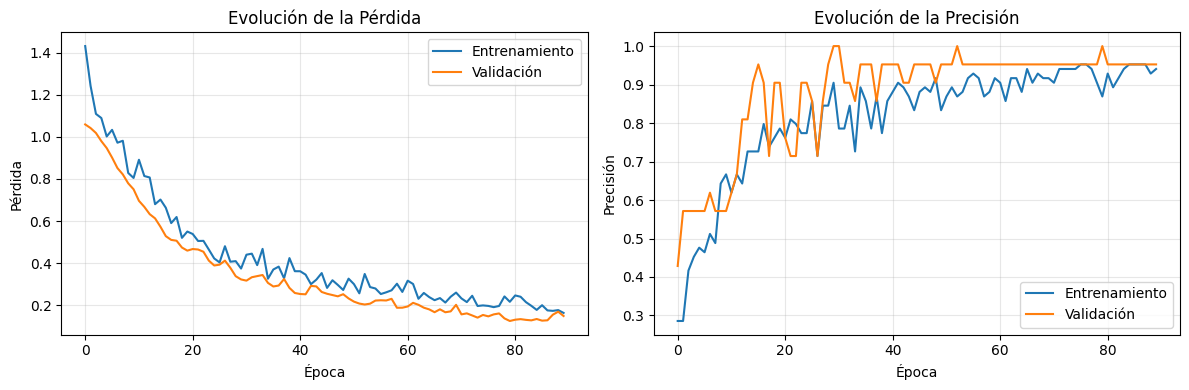

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
axes[0].plot(history_tf.history['loss'], label='Entrenamiento')
axes[0].plot(history_tf.history['val_loss'], label='Validación')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Evolución de la Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precisión
axes[1].plot(history_tf.history['accuracy'], label='Entrenamiento')
axes[1].plot(history_tf.history['val_accuracy'], label='Validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Evolución de la Precisión')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. PyTorch: Estructura y Ejemplos

### 5.1. Estructura de PyTorch

```
┌─────────────────────────────────────────────────────────────┐
│                    PyTorch Architecture                    │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  1. Tensors                                                │
│     └── Estructura de datos multidimensional               │
│     └── torch.tensor, torch.FloatTensor, etc.             │
│     └── .cuda() para mover a GPU                          │
│                                                             │
│  2. Autograd (Automatic Differentiation)                   │
│     └── Calcula gradientes automáticamente                 │
│     └── .requires_grad = True                              │
│     └── .backward() para retropropagación                 │
│                                                             │
│  3. nn.Module                                              │
│     └── Clase base para todos los modelos                  │
│     └── Definir __init__() y forward()                    │
│     └── torch.nn.Linear, Conv2d, LSTM, etc.               │
│                                                             │
│  4. Optimizadores                                          │
│     └── torch.optim.SGD, Adam, RMSprop                    │
│     └── optimizer.zero_grad(), .step()                    │
│                                                             │
│  5. DataLoaders                                            │
│     └── torch.utils.data.DataLoader                       │
│     └── Dataset, DataLoader, Sampler                      │
│                                                             │
│  6. Device                                                 │
│     └── torch.device('cuda' if torch.cuda.is_available()  │
│                        else 'cpu')                         │
└─────────────────────────────────────────────────────────────┘
```

### 5.2. Ejemplo: Clasificación con PyTorch

In [44]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Definir modelo (clase que hereda de nn.Module)
class IrisClassifier(nn.Module):
    def __init__(self):
        super(IrisClassifier, self).__init__()
        self.fc1 = nn.Linear(4, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3)
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return F.softmax(x, dim=1)

# Crear modelo
model_torch = IrisClassifier()

# Mover a GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_torch = model_torch.to(device)
print(f"Modelo en: {device}")

# Convertir datos a tensores de PyTorch
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_torch = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_torch = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_torch = torch.tensor(y_test, dtype=torch.long).to(device)

# Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.001)

# Entrenar
epochs = 100
batch_size = 16
n_batches = len(X_train_torch) // batch_size

history_torch = {'loss': [], 'acc': []}

for epoch in range(epochs):
    model_torch.train()
    epoch_loss = 0
    
    for i in range(n_batches):
        start = i * batch_size
        end = start + batch_size
        
        X_batch = X_train_torch[start:end]
        y_batch = y_train_torch[start:end]
        
        # Forward
        outputs = model_torch(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Evaluar en entrenamiento
    model_torch.eval()
    with torch.no_grad():
        outputs = model_torch(X_train_torch)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train_torch).float().mean().item()
    
    history_torch['loss'].append(epoch_loss / n_batches)
    history_torch['acc'].append(acc)

print("Entrenamiento completado")

# Evaluar en test
model_torch.eval()
with torch.no_grad():
    outputs = model_torch(X_test_torch)
    _, predicted = torch.max(outputs, 1)
    acc_test = (predicted == y_test_torch).float().mean().item()

print(f"Accuracy en test: {acc_test:.4f}")

Modelo en: cpu
Entrenamiento completado
Accuracy en test: 1.0000


### 5.3. Visualización del Entrenamiento PyTorch

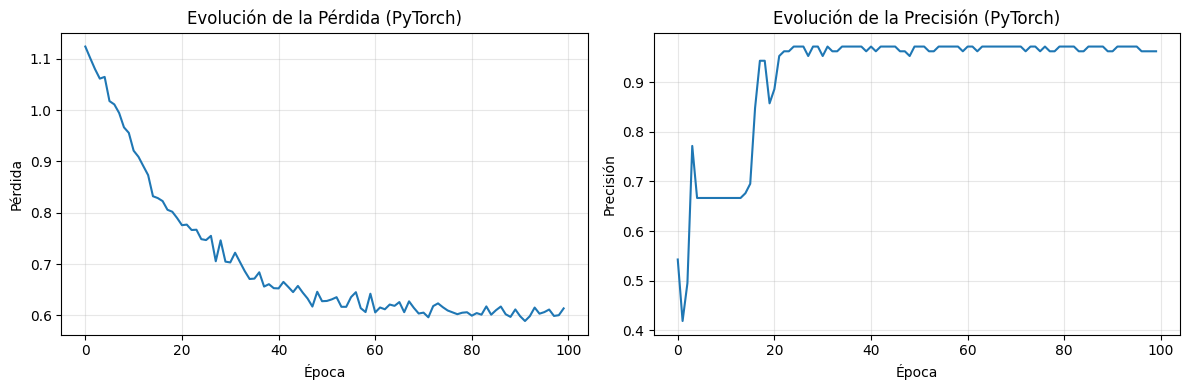

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
axes[0].plot(history_torch['loss'])
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Evolución de la Pérdida (PyTorch)')
axes[0].grid(True, alpha=0.3)

# Precisión
axes[1].plot(history_torch['acc'])
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Evolución de la Precisión (PyTorch)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Comparación de Frameworks

### 6.1. Cuadro Comparativo

| **Característica** | **Scikit-learn** | **TensorFlow** | **PyTorch** |
|-------------------|------------------|----------------|-------------|
| **Propósito** | ML tradicional | DL y producción | DL e investigación |
| **Nivel de abstracción** | Alto | Medio-Alto | Medio |
| **Curva de aprendizaje** | Baja | Media | Media-Alta |
| **GPU soporte** | No (usa NumPy) | Sí | Sí |
| **Gráficos computacionales** | No | Estático/Dinámico | Dinámico |
| **Depuración** | Fácil (Python) | Media | Fácil (Python) |
| **Comunidad** | Muy grande | Muy grande | Muy grande |
| **Ideal para** | Prototipado rápido | Producción / Escalado | Investigación / Flexibilidad |

### 6.2. Cuándo usar cada uno

- **Scikit-learn**:
  - Datos tabulares, tamaño moderado
  - Modelos tradicionales (regresión, SVM, árboles)
  - Prototipado rápido
  - Sin necesidad de GPU

- **TensorFlow**:
  - Proyectos de producción
  - Modelos grandes con necesidad de escalado
  - Despliegue en móvil/edge (TensorFlow Lite)
  - Integración con ecosistema Google

- **PyTorch**:
  - Investigación en DL
  - Modelos dinámicos o personalizados
  - Debugging avanzado
  - Prototipado rápido de nuevas arquitecturas

## 7. Ejercicios Prácticos

### Ejercicio 1: Exploración de Tensores

Crea un tensor en NumPy, TensorFlow y PyTorch con las mismas dimensiones y realiza operaciones básicas (suma, multiplicación, transposición).

In [46]:
# --- SOLUCIÓN ---

# NumPy
A_np = np.array([[1, 2, 3], [4, 5, 6]])
print("NumPy:\n", A_np)
print("Transpuesta:\n", A_np.T)

# TensorFlow
A_tf = tf.constant([[1, 2, 3], [4, 5, 6]])
print("\nTensorFlow:\n", A_tf.numpy())
print("Transpuesta:\n", tf.transpose(A_tf).numpy())

# PyTorch
A_torch = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("\nPyTorch:\n", A_torch.numpy())
print("Transpuesta:\n", A_torch.T.numpy())

NumPy:
 [[1 2 3]
 [4 5 6]]
Transpuesta:
 [[1 4]
 [2 5]
 [3 6]]

TensorFlow:
 [[1 2 3]
 [4 5 6]]
Transpuesta:
 [[1 4]
 [2 5]
 [3 6]]

PyTorch:
 [[1 2 3]
 [4 5 6]]
Transpuesta:
 [[1 4]
 [2 5]
 [3 6]]


### Ejercicio 2: Crear un Pipeline en Scikit-learn

Crea un pipeline que:
1. Estandarice los datos
2. Reduzca a 2 componentes con PCA
3. Clasifique con RandomForest

Entrena y evalúa el modelo.

In [47]:
# --- SOLUCIÓN ---
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
print(f"Accuracy RandomForest: {pipeline_rf.score(X_test, y_test):.4f}")

Accuracy RandomForest: 0.9333


### Ejercicio 3: Comparar Velocidad

Modifica el código de comparación de matrices para medir el tiempo de:
- Multiplicación de matrices de tamaño 2000x2000
- Con diferentes precisiones (float32 vs float64)
- Con diferentes backends

In [48]:
# --- SOLUCIÓN ---
n = 2000
A = np.random.randn(n, n).astype(np.float32)
B = np.random.randn(n, n).astype(np.float32)

# Medir tiempos
_, t_np = medir_tiempo(np.matmul, A, B)
print(f"NumPy float32: {t_np:.4f} seg")

# float64
A_f64 = A.astype(np.float64)
B_f64 = B.astype(np.float64)
_, t_np_f64 = medir_tiempo(np.matmul, A_f64, B_f64)
print(f"NumPy float64: {t_np_f64:.4f} seg")

print(f"Diferencia: {t_np_f64/t_np:.2f}x")

NumPy float32: 0.0644 seg
NumPy float64: 0.1228 seg
Diferencia: 1.91x



### Recomendaciones 
1. **Usar Scikit-learn** para:
   - Modelos tradicionales
   - Prototipado rápido
   - Preprocesamiento y pipelines

2. **Usar TensorFlow para**:
   - Modelos grandes
   - Producción y despliegue
   - Proyectos que requieren escalado

3. **Usar PyTorch para**:
   - Investigación
   - Modelos personalizados
   - Debugging avanzado

4. **Aprovechar GPU** cuando:
   - Modelos grandes o profundos
   - Grandes volúmenes de datos
   - Entrenamiento prolongado

---
